In [1]:
from gentropy.common.session import Session
from gentropy.dataset.study_index import StudyIndex
from gentropy.dataset.study_locus import StudyLocus
from gentropy.dataset.variant_index import VariantIndex
from gentropy.method.drug_enrichment_from_evid import chemblDrugEnrichment
from pyspark.sql import functions as f


Loading BokehJS ...

/Users/yt4/Projects/Gentropy-manuscript/.venv/lib/python3.11/site-packages/pyspark/sql/pandas/functions.py:407: UserWarning:

In Python 3.6+ and Spark 3.0+, it is preferred to specify type hints for pandas UDF instead of specifying pandas UDF type which will be deprecated in the future releases. See SPARK-28264 for more details.



In [2]:
session = Session(extended_spark_conf={"spark.driver.memory": "40G"})


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/02/09 12:40:30 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
path_to_release_folder = "../../../data/25.06/"
path_to_intermediate_data_folder = "../../../data/intermediate_files/"

sl = StudyLocus.from_parquet(session, path_to_release_folder + "output/credible_set")
si = StudyIndex.from_parquet(session, path_to_release_folder + "output/study")

disease_index_path = path_to_release_folder + "output/disease/disease.parquet"
disease_index_orig = session.spark.read.parquet(disease_index_path)

platform_chembl_evidence_path = path_to_release_folder + "output/evidence/sourceId=chembl"
chembl_evidence = session.spark.read.parquet(platform_chembl_evidence_path)

all_evidence = session.spark.read.parquet(path_to_release_folder + "output/evidence")


efo_to_remove = chemblDrugEnrichment.selecting_all_decendands_based_on_efo_list(
    disease_index_orig=disease_index_orig,
    efo_ids="MONDO_0045024",
)

chembl_evidence.show(1)

l2g_full = session.spark.read.parquet(path_to_intermediate_data_folder + "l2g_full_for_enrichment/")
l2g_full.count()

l2g_full.show(1)


g_p_s = session.spark.read.parquet(path_to_intermediate_data_folder + "genes_therapeutic_areas")
g_p_s.count()


26/02/09 12:40:35 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+------------+---------------+-------------+-------------------+--------+----------+----+---------------------------+---------------------------+---------------------------------+--------------------------------+-----------------+-------------+----------+--------------------+--------+-------------+---------------------+--------------+-----------------+--------+----------------+---------------+----------+--------+-------------------+----------+----------------+--------------------+-------------------+-------------------------+-------------------------------------+-------------------------------------+--------------+----------+------------+-----------------+----------+----------------------------+-------------------+--------------+---------+--------------------------------+--------------------------------+--------------+--------------+--------+---------+----------+------------+-----------+--------------+-------------+----+------------------------+-----------------+-----------------------

8285

# Load data


In [4]:
import pandas as pd

df_for_regression = pd.read_csv(path_to_intermediate_data_folder + "df_for_enrichment_regression.csv")


In [5]:
df_for_regression


,targetId,diseaseId,indirect_assoc_score,max_beta,min_maf,max_vep,maxClinicalPhase,uniqueDiseases,uniqueTherapeuticAreas,outcome,geneticSupport
0,ENSG00000004779,MONDO_0020121,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0,0
1,ENSG00000011677,EFO_0005411,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0,0
2,ENSG00000018625,EFO_0000544,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,0
3,ENSG00000022355,EFO_0007634,0.0,0.0,0.0,0.0,2.0,1.0,1.0,0,0
4,ENSG00000053918,EFO_0000546,0.0,0.0,0.0,0.0,2.0,18.0,11.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
37372,ENSG00000273079,EFO_0003108,0.0,0.0,0.0,0.0,2.0,1.0,1.0,0,0
37373,ENSG00000274286,EFO_0005207,0.0,0.0,0.0,0.0,3.0,1.0,1.0,0,0
37374,ENSG00000274286,MONDO_0001330,0.0,0.0,0.0,0.0,3.0,1.0,1.0,0,0
37375,ENSG00000274286,Orphanet_1764,0.0,0.0,0.0,0.0,2.0,1.0,1.0,0,0


# Chembl


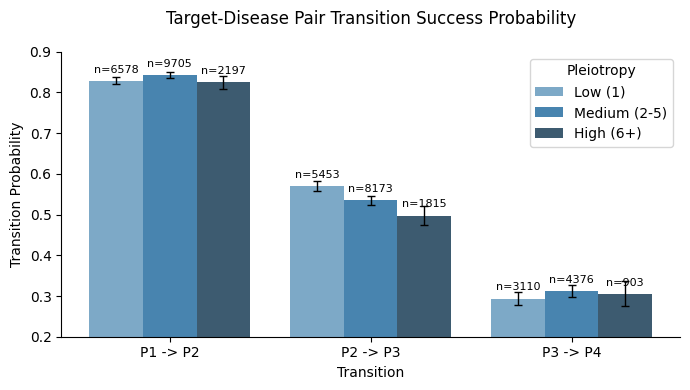

Pleiotropy  High (6+)  Low (1)  Medium (2-5)
Transition                                  
P1 -> P2        0.826    0.829         0.842
P2 -> P3        0.498    0.570         0.535
P3 -> P4        0.306    0.294         0.312


In [11]:
# ...existing code...
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from statsmodels.stats.proportion import proportion_confint

# ...existing code...

# 1. Группировка
df_phase = df_for_regression.copy()
# Используем ручные границы для биологического смысла
bins = [0, 1, 5, float("inf")]
labels = ["Low (1)", "Medium (2-5)", "High (6+)"]
df_phase["pleio_bin"] = pd.cut(df_phase["uniqueTherapeuticAreas"], bins=bins, labels=labels)

# 2. Расчет переходов
transitions = [(1, 2, "P1 -> P2"), (2, 3, "P2 -> P3"), (3, 4, "P3 -> P4")]
transition_results = []

for label in labels:
    subset = df_phase[df_phase["pleio_bin"] == label]
    for start_f, end_f, name in transitions:
        # Кто дошел до текущей фазы
        at_start = len(subset[subset["maxClinicalPhase"] >= start_f])
        # Кто из них прошел в следующую
        at_end = len(subset[subset["maxClinicalPhase"] >= end_f])

        rate = at_end / at_start if at_start > 0 else 0
        if at_start > 0:
            ci_low, ci_high = proportion_confint(at_end, at_start, alpha=0.05, method="wilson")
        else:
            ci_low, ci_high = 0, 0

        transition_results.append(
            {
                "Pleiotropy": label,
                "Transition": name,
                "Success Rate": rate,
                "N_at_start": at_start,
                "ci_low": ci_low,
                "ci_high": ci_high,
            }
        )

trans_df = pd.DataFrame(transition_results)

# ...existing code...
# 3. Визуализация
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(
    data=trans_df,
    x="Transition",
    y="Success Rate",
    hue="Pleiotropy",
    order=[t[2] for t in transitions],
    hue_order=labels,
    palette="Blues_d",
    ax=ax,
)

# Добавляем error bars (CIs)
for h_i, label in enumerate(labels):
    for t_i, (_, _, name) in enumerate(transitions):
        row = trans_df[(trans_df["Pleiotropy"] == label) & (trans_df["Transition"] == name)].iloc[0]
        bar = ax.containers[h_i].patches[t_i]
        x = bar.get_x() + bar.get_width() / 2.0
        y = row["Success Rate"]
        yerr = [[y - row["ci_low"]], [row["ci_high"] - y]]
        ax.errorbar(
            x=x,
            y=y,
            yerr=yerr,
            fmt="none",
            ecolor="black",
            elinewidth=1,
            capsize=3,
            zorder=10,
        )
# ...existing code...

# Добавляем n=... над столбцами
for i, p in enumerate(ax.patches):
    height = p.get_height()
    if height > 0:
        ax.text(
            p.get_x() + p.get_width() / 2.0,
            height + 0.02,
            f"n={trans_df['N_at_start'].iloc[i]}",
            ha="center",
            fontsize=8,
        )

ax.set_ylim(0.2, 0.9)
ax.set_ylabel("Transition Probability")
ax.set_title("Target-Disease Pair Transition Success Probability", pad=20)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

# Печатаем таблицу для контроля
print(trans_df.pivot(index="Transition", columns="Pleiotropy", values="Success Rate").round(3))


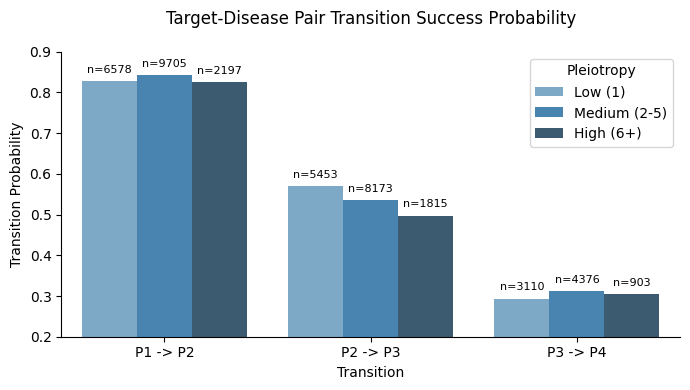

Pleiotropy  High (6+)  Low (1)  Medium (2-5)
Transition                                  
P1 -> P2        0.826    0.829         0.842
P2 -> P3        0.498    0.570         0.535
P3 -> P4        0.306    0.294         0.312


In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Группировка
df_phase = df_for_regression.copy()
# Используем ручные границы для биологического смысла
bins = [0, 1, 5, float("inf")]
labels = ["Low (1)", "Medium (2-5)", "High (6+)"]
df_phase["pleio_bin"] = pd.cut(df_phase["uniqueTherapeuticAreas"], bins=bins, labels=labels)

# 2. Расчет переходов
transitions = [(1, 2, "P1 -> P2"), (2, 3, "P2 -> P3"), (3, 4, "P3 -> P4")]
transition_results = []

for label in labels:
    subset = df_phase[df_phase["pleio_bin"] == label]
    for start_f, end_f, name in transitions:
        # Кто дошел до текущей фазы
        at_start = len(subset[subset["maxClinicalPhase"] >= start_f])
        # Кто из них прошел в следующую
        at_end = len(subset[subset["maxClinicalPhase"] >= end_f])

        rate = at_end / at_start if at_start > 0 else 0
        transition_results.append(
            {"Pleiotropy": label, "Transition": name, "Success Rate": rate, "N_at_start": at_start}
        )

trans_df = pd.DataFrame(transition_results)

# 3. Визуализация
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=trans_df, x="Transition", y="Success Rate", hue="Pleiotropy", palette="Blues_d", ax=ax)

# Добавляем n=... над столбцами
for i, p in enumerate(ax.patches):
    height = p.get_height()
    if height > 0:
        ax.text(
            p.get_x() + p.get_width() / 2.0,
            height + 0.02,
            f"n={trans_df['N_at_start'].iloc[i]}",
            ha="center",
            fontsize=8,
        )

ax.set_ylim(0.2, 0.9)
ax.set_ylabel("Transition Probability")
ax.set_title("Target-Disease Pair Transition Success Probability", pad=20)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

# Печатаем таблицу для контроля
print(trans_df.pivot(index="Transition", columns="Pleiotropy", values="Success Rate").round(3))


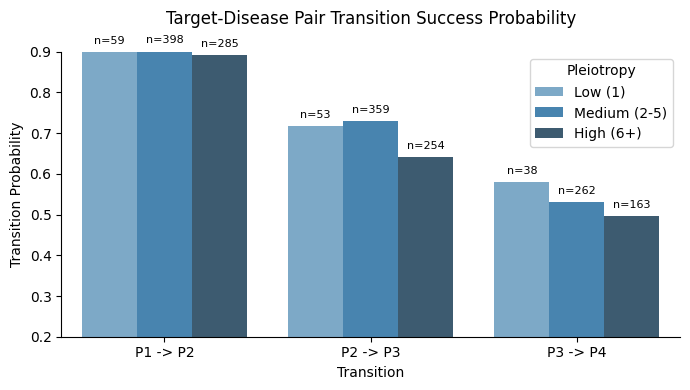

Pleiotropy  High (6+)  Low (1)  Medium (2-5)
Transition                                  
P1 -> P2        0.891    0.898         0.902
P2 -> P3        0.642    0.717         0.730
P3 -> P4        0.497    0.579         0.531


In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Группировка
df_phase = df_for_regression[df_for_regression["geneticSupport"] == 1].copy()
# Используем ручные границы для биологического смысла
bins = [0, 1, 5, float("inf")]
labels = ["Low (1)", "Medium (2-5)", "High (6+)"]
df_phase["pleio_bin"] = pd.cut(df_phase["uniqueTherapeuticAreas"], bins=bins, labels=labels)

# 2. Расчет переходов
transitions = [(1, 2, "P1 -> P2"), (2, 3, "P2 -> P3"), (3, 4, "P3 -> P4")]
transition_results = []

for label in labels:
    subset = df_phase[df_phase["pleio_bin"] == label]
    for start_f, end_f, name in transitions:
        # Кто дошел до текущей фазы
        at_start = len(subset[subset["maxClinicalPhase"] >= start_f])
        # Кто из них прошел в следующую
        at_end = len(subset[subset["maxClinicalPhase"] >= end_f])

        rate = at_end / at_start if at_start > 0 else 0
        transition_results.append(
            {"Pleiotropy": label, "Transition": name, "Success Rate": rate, "N_at_start": at_start}
        )

trans_df = pd.DataFrame(transition_results)

# 3. Визуализация
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=trans_df, x="Transition", y="Success Rate", hue="Pleiotropy", palette="Blues_d", ax=ax)

# Добавляем n=... над столбцами
for i, p in enumerate(ax.patches):
    height = p.get_height()
    if height > 0:
        ax.text(
            p.get_x() + p.get_width() / 2.0,
            height + 0.02,
            f"n={trans_df['N_at_start'].iloc[i]}",
            ha="center",
            fontsize=8,
        )

ax.set_ylim(0.2, 0.9)
ax.set_ylabel("Transition Probability")
ax.set_title("Target-Disease Pair Transition Success Probability", pad=20)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

# Печатаем таблицу для контроля
print(trans_df.pivot(index="Transition", columns="Pleiotropy", values="Success Rate").round(3))


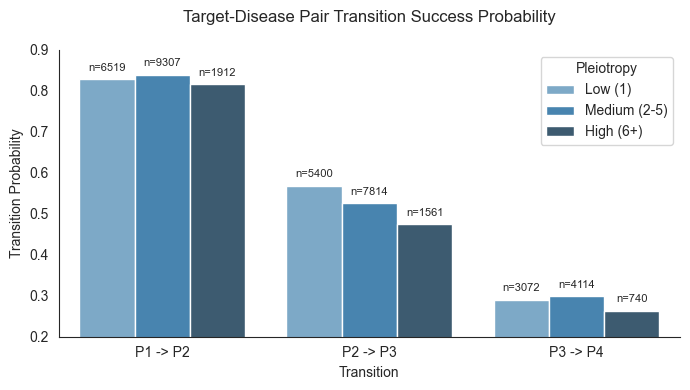

Pleiotropy  High (6+)  Low (1)  Medium (2-5)
Transition                                  
P1 -> P2        0.816    0.828         0.840
P2 -> P3        0.474    0.569         0.526
P3 -> P4        0.264    0.290         0.298


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Группировка
df_phase = df_for_regression[df_for_regression["geneticSupport"] == 0].copy()
# Используем ручные границы для биологического смысла
bins = [0, 1, 5, float("inf")]
labels = ["Low (1)", "Medium (2-5)", "High (6+)"]
df_phase["pleio_bin"] = pd.cut(df_phase["uniqueTherapeuticAreas"], bins=bins, labels=labels)

# 2. Расчет переходов
transitions = [(1, 2, "P1 -> P2"), (2, 3, "P2 -> P3"), (3, 4, "P3 -> P4")]
transition_results = []

for label in labels:
    subset = df_phase[df_phase["pleio_bin"] == label]
    for start_f, end_f, name in transitions:
        # Кто дошел до текущей фазы
        at_start = len(subset[subset["maxClinicalPhase"] >= start_f])
        # Кто из них прошел в следующую
        at_end = len(subset[subset["maxClinicalPhase"] >= end_f])

        rate = at_end / at_start if at_start > 0 else 0
        transition_results.append(
            {"Pleiotropy": label, "Transition": name, "Success Rate": rate, "N_at_start": at_start}
        )

trans_df = pd.DataFrame(transition_results)

# 3. Визуализация
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=trans_df, x="Transition", y="Success Rate", hue="Pleiotropy", palette="Blues_d", ax=ax)

# Добавляем n=... над столбцами
for i, p in enumerate(ax.patches):
    height = p.get_height()
    if height > 0:
        ax.text(
            p.get_x() + p.get_width() / 2.0,
            height + 0.02,
            f"n={trans_df['N_at_start'].iloc[i]}",
            ha="center",
            fontsize=8,
        )

ax.set_ylim(0.2, 0.9)
ax.set_ylabel("Transition Probability")
ax.set_title("Target-Disease Pair Transition Success Probability", pad=20)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

# Печатаем таблицу для контроля
print(trans_df.pivot(index="Transition", columns="Pleiotropy", values="Success Rate").round(3))


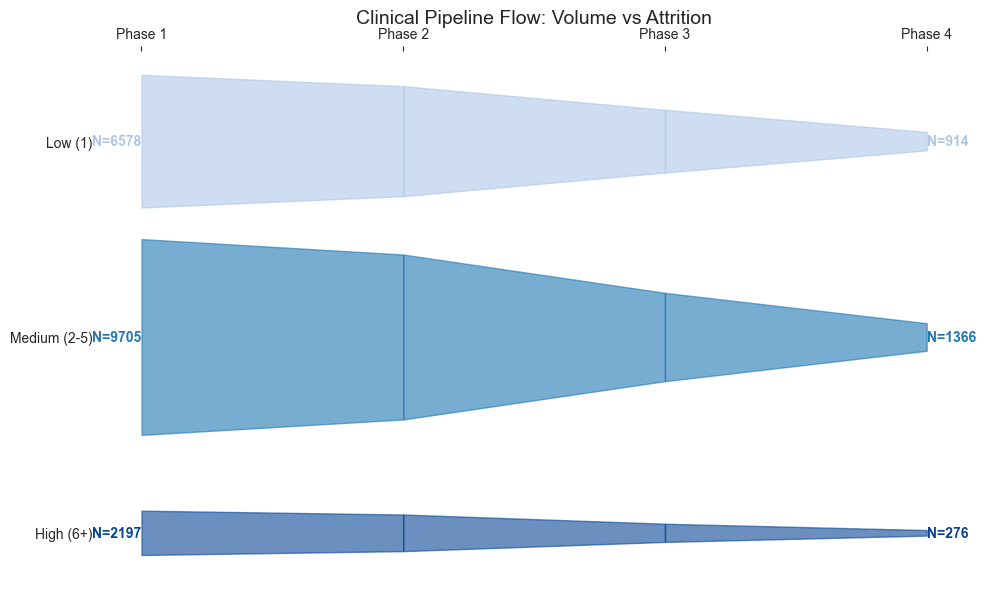

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Собираем данные об абсолютных количествах (N)
funnel_data = []
for label in labels:
    subset = df_phase[df_phase["pleio_bin"] == label]
    counts = [len(subset[subset["maxClinicalPhase"] >= f]) for f in [1, 2, 3, 4]]
    funnel_data.append({"Group": label, "Counts": counts})

# 2. Визуализация: Сравнение "толщины" потока
fig, ax = plt.subplots(figsize=(10, 6))

phases = ["Phase 1", "Phase 2", "Phase 3", "Phase 4"]
colors = ["#aec7e8", "#1f77b4", "#084594"]  # Оттенки синего для разных групп

for i, data in enumerate(funnel_data):
    # Рисуем линию, где толщина (linewidth) зависит от количества N
    # Используем логарифмическую шкалу для ширины, если разница в N огромная
    widths = np.array(data["Counts"])
    # Нормализуем ширину для отрисовки (чтобы самая толстая была, например, 20)
    scaled_widths = (widths / max([max(d["Counts"]) for d in funnel_data])) * 50

    line = ax.plot(phases, [3 - i] * 4, label=data["Group"], color=colors[i], lw=0)  # невидимая база

    # Рисуем "тело" воронки для каждой группы
    for j in range(len(phases) - 1):
        ax.fill_between(
            phases[j : j + 2],
            [3 - i - scaled_widths[j] / 100, 3 - i - scaled_widths[j + 1] / 100],
            [3 - i + scaled_widths[j] / 100, 3 - i + scaled_widths[j + 1] / 100],
            color=colors[i],
            alpha=0.6,
        )

    # Добавляем цифры N в начале и конце
    ax.text(phases[0], 3 - i, f"N={widths[0]}", ha="right", va="center", fontweight="bold", color=colors[i])
    ax.text(phases[-1], 3 - i, f"N={widths[-1]}", ha="left", va="center", fontweight="bold", color=colors[i])

ax.set_yticks([1, 2, 3])
ax.set_yticklabels(reversed(labels))
ax.set_title("Clinical Pipeline Flow: Volume vs Attrition", fontsize=14, pad=20)
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax.get_xaxis().set_ticks_position("top")
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

# 1. Подготовка данных
df_phase = df_for_regression.copy()
bins = [0, 1, 5, float("inf")]
labels = ["Low (1)", "Medium (2-5)", "High (6+)"]
df_phase["pleio_bin"] = pd.cut(df_phase["uniqueTherapeuticAreas"], bins=bins, labels=labels)

transitions = [(1, 2, "P1 -> P2"), (2, 3, "P2 -> P3"), (3, 4, "P3 -> P4")]
final_rows = []

for start_f, end_f, stage_name in transitions:
    stats = {}
    contingency_table = []

    for label in labels:
        subset = df_phase[df_phase["pleio_bin"] == label]
        n_in = len(subset[subset["maxClinicalPhase"] >= start_f])
        n_out = len(subset[subset["maxClinicalPhase"] >= end_f])
        n_fail = n_in - n_out
        rate = (n_out / n_in * 100) if n_in > 0 else 0

        stats[label] = {"n": n_in, "rate": rate}
        contingency_table.append([n_out, n_fail])

    # Считаем общий P-value (Chi-square) для этапа: влияет ли плейотропия на успех?
    chi2, p_val, dof, ex = chi2_contingency(contingency_table)

    final_rows.append(
        {
            "Stage": stage_name,
            "Low (N)": stats["Low (1)"]["n"],
            "Low %": f"{stats['Low (1)']['rate']:.1f}%",
            "Medium (N)": stats["Medium (2-5)"]["n"],
            "Medium %": f"{stats['Medium (2-5)']['rate']:.1f}%",
            "High (N)": stats["High (6+)"]["n"],
            "High %": f"{stats['High (6+)']['rate']:.1f}%",
            "Overall P-value": f"{p_val:.4f}",
        }
    )

# 2. Оформление таблицы
table_complete = pd.DataFrame(final_rows)
print(table_complete.to_string(index=False))


   Stage  Low (N) Low %  Medium (N) Medium %  High (N) High % Overall P-value
P1 -> P2     6578 82.9%        9705    84.2%      2197  82.6%          0.0376
P2 -> P3     5453 57.0%        8173    53.5%      1815  49.8%          0.0000
P3 -> P4     3110 29.4%        4376    31.2%       903  30.6%          0.2384


In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest

# 1. Подготовка данных и группировка
df_phase = df_for_regression.copy()
bins = [0, 1, 5, float("inf")]
labels = ["Low (1)", "Medium (2-5)", "High (6+)"]
df_phase["pleio_bin"] = pd.cut(df_phase["uniqueTherapeuticAreas"], bins=bins, labels=labels)

transitions = [(1, 2, "Phase 1 -> 2"), (2, 3, "Phase 2 -> 3"), (3, 4, "Phase 3 -> 4")]
table_rows = []

for start_f, end_f, stage_name in transitions:
    stats = {}
    contingency = []

    # Сбор базовой статистики по группам
    for label in labels:
        subset = df_phase[df_phase["pleio_bin"] == label]
        n_in = len(subset[subset["maxClinicalPhase"] >= start_f])
        n_out = len(subset[subset["maxClinicalPhase"] >= end_f])
        rate = (n_out / n_in * 100) if n_in > 0 else 0

        stats[label] = {"n_in": n_in, "n_out": n_out, "rate": rate}
        contingency.append([n_out, n_in - n_out])

    # --- СТАТИСТИЧЕСКИЕ ТЕСТЫ ---

    # 1. Omnibus Chi-square (Общая разница между всеми группами)
    _, p_omnibus, _, _ = chi2_contingency(contingency)

    # 2. Pairwise Z-test: High vs Low
    count_hl = [stats["High (6+)"]["n_out"], stats["Low (1)"]["n_out"]]
    nobs_hl = [stats["High (6+)"]["n_in"], stats["Low (1)"]["n_in"]]
    _, p_h_vs_l = proportions_ztest(count_hl, nobs_hl) if all(n > 0 for n in nobs_hl) else (0, 1)

    # 3. Pairwise Z-test: High vs Medium
    count_hm = [stats["High (6+)"]["n_out"], stats["Medium (2-5)"]["n_out"]]
    nobs_hm = [stats["High (6+)"]["n_in"], stats["Medium (2-5)"]["n_in"]]
    _, p_h_vs_m = proportions_ztest(count_hm, nobs_hm) if all(n > 0 for n in nobs_hm) else (0, 1)

    # Формирование строки
    table_rows.append(
        {
            "Transition": stage_name,
            "Low (N)": stats["Low (1)"]["n_in"],
            "Low %": f"{stats['Low (1)']['rate']:.1f}%",
            "Medium (N)": stats["Medium (2-5)"]["n_in"],
            "Medium %": f"{stats['Medium (2-5)']['rate']:.1f}%",
            "High (N)": stats["High (6+)"]["n_in"],
            "High %": f"{stats['High (6+)']['rate']:.1f}%",
            "P (Omnibus)": f"{p_omnibus:.4f}",
            "P (High vs Low)": f"{p_h_vs_l:.4f}",
            "P (High vs Med)": f"{p_h_vs_m:.4f}",
        }
    )

# Создание финального DataFrame
final_table = pd.DataFrame(table_rows)

# Форматирование P-values для публикации (замена 0.0000 на <0.001)
p_cols = ["P (Omnibus)", "P (High vs Low)", "P (High vs Med)"]
# for col in p_cols:
#    final_table[col] = final_table[col].apply(lambda x: "<0.001" if float(x) < 0.001 else x)

print("SUMMARY ATTRITION TABLE BY PLEIOTROPY LEVEL")
print("=" * 110)
print(final_table.to_string(index=False))
print("=" * 110)


SUMMARY ATTRITION TABLE BY PLEIOTROPY LEVEL
  Transition  Low (N) Low %  Medium (N) Medium %  High (N) High % P (Omnibus) P (High vs Low) P (High vs Med)
Phase 1 -> 2     6578 82.9%        9705    84.2%      2197  82.6%      0.0376          0.7592          0.0650
Phase 2 -> 3     5453 57.0%        8173    53.5%      1815  49.8%      0.0000          0.0000          0.0034
Phase 3 -> 4     3110 29.4%        4376    31.2%       903  30.6%      0.2384          0.4959          0.7004


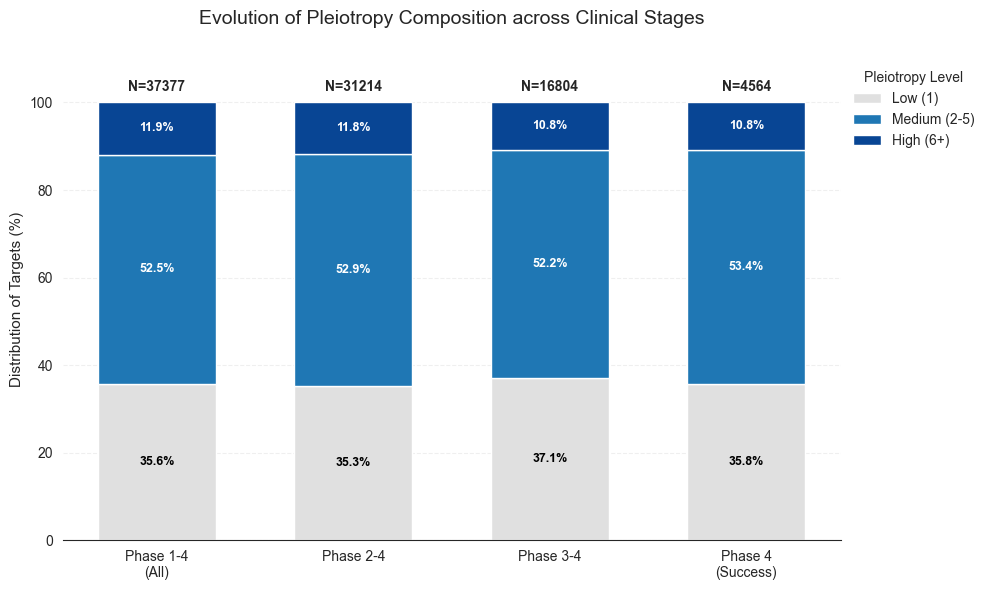

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Подготовка данных
df_phase = df_for_regression.copy()
bins = [0, 1, 5, float("inf")]
labels = ["Low (1)", "Medium (2-5)", "High (6+)"]
df_phase["pleio_bin"] = pd.cut(df_phase["uniqueTherapeuticAreas"], bins=bins, labels=labels)

# 2. Сбор данных для колонок
plot_data = []
phase_thresholds = [1, 2, 3, 4]
column_names = ["Phase 1-4\n(All)", "Phase 2-4", "Phase 3-4", "Phase 4\n(Success)"]

for p in phase_thresholds:
    # Берем только те пары, которые достигли этой фазы или выше
    subset = df_phase[df_phase["maxClinicalPhase"] >= p]
    counts = subset["pleio_bin"].value_counts(normalize=True).reindex(labels) * 100
    total_n = len(subset)
    plot_data.append({"counts": counts.values, "total_n": total_n})

# Преобразуем в удобный формат для построения
data_matrix = np.array([d["counts"] for d in plot_data]).T  # Строки - группы, столбцы - фазы

# 3. Визуализация
fig, ax = plt.subplots(figsize=(10, 6))

# Цвета: от светлого к темному (High - самый темный/акцентный)
colors = ["#e0e0e0", "#1f77b4", "#084594"]
bottom = np.zeros(len(phase_thresholds))

for i, label in enumerate(labels):
    ax.bar(column_names, data_matrix[i], bottom=bottom, label=label, color=colors[i], width=0.6)

    # Добавляем текстовые подписи процентов внутри сегментов
    for j in range(len(column_names)):
        val = data_matrix[i][j]
        if val > 5:  # Рисуем текст только если сегмент достаточно большой
            ax.text(
                j,
                bottom[j] + val / 2,
                f"{val:.1f}%",
                ha="center",
                va="center",
                color="white" if i > 0 else "black",
                fontweight="bold",
                fontsize=9,
            )

    bottom += data_matrix[i]

# Добавляем общее N над каждым столбиком
for j, d in enumerate(plot_data):
    ax.text(j, 102, f"N={d['total_n']}", ha="center", va="bottom", fontsize=10, fontweight="bold")

# Оформление
ax.set_ylabel("Distribution of Targets (%)", fontsize=11)
ax.set_title("Evolution of Pleiotropy Composition across Clinical Stages", fontsize=14, pad=25)
ax.set_ylim(0, 110)
ax.legend(loc="upper left", bbox_to_anchor=(1, 1), frameon=False, title="Pleiotropy Level")

# Тонкая настройка сетки
ax.yaxis.grid(True, linestyle="--", alpha=0.3)
ax.spines[["top", "right", "left"]].set_visible(False)

plt.tight_layout()
plt.show()


# Pharmackoproject data from Minikel et al.


In [4]:
phrm_df = session.spark.read.csv(
    path_to_intermediate_data_folder + "minikel_etal_processed_data_v2.csv", header=True, inferSchema=True
)


In [5]:
phrm_df.count()


7390

In [6]:
phrm_df.show(1)


+---------------+-------------+-------+--------------+-----------+----------+------+-----------+--------------------+---------+----+---------+-------+-------+-------+--------+--------+--------+--------+------+-----------+----+-------------+--------------------+------------+----------+------------------+--------------------+----------+------------+------+-----------------+---------+--------+---------+-----------+----------+--------------------------------+---------------+------------------+-------------------+--------------------+-------+------------------+--------------+----------------------+--------------+----------------+
|       targetId|    diseaseId| meshId|approvedSymbol|        uid|similarity|catnum|     ti_uid|indication_mesh_term|     hcat|acat|     ccat|hcatnum|acatnum|ccatnum|succ_p_1|succ_1_2|succ_2_3|succ_3_a|orphan|year_launch|arow|assoc_mesh_id|     assoc_mesh_term|assoc_source|assoc_info|    original_trait|       original_link|assoc_year|pic_qtl_pval|pic_h4|    af_gnom

In [7]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf


In [ ]:
df = phrm_df.toPandas()

model2 = smf.logit(
    "outcome ~ geneticSupport_old+I(np.log(uniqueDiseases+1))+I(np.log(uniqueDiseases+1) ** 2)", data=df
).fit(disp=False)
model1 = smf.logit("outcome ~ geneticSupport_old+I(np.log(uniqueDiseases+1))", data=df).fit(disp=False)
model0 = smf.logit("outcome ~ geneticSupport_old", data=df).fit(disp=False)
from scipy.stats import chi2


def lr_test(model_full, model_restricted):
    """Likelihood-ratio test for nested models.
    Returns (LR_stat, pvalue, df_diff).
    """
    llf_full = float(model_full.llf)
    llf_red = float(model_restricted.llf)
    k_full = len(model_full.params)
    k_red = len(model_restricted.params)
    df_diff = k_full - k_red
    if df_diff <= 0:
        raise ValueError("models are not nested in the expected direction (full must have more params)")
    LR = 2.0 * (llf_full - llf_red)
    pval = chi2.sf(LR, df_diff)
    return LR, pval, df_diff


# compare models
LR20, p20, df20 = lr_test(model2, model0)  # model2 vs model0
LR10, p10, df10 = lr_test(model1, model0)  # model1 vs model0
LR21, p21, df21 = lr_test(model2, model1)  # model2 vs model1

print(f"model2 vs model0: LR={LR20:.3f}, df={df20}, p={p20:.3g}")
print(f"model1 vs model0: LR={LR10:.3f}, df={df10}, p={p10:.3g}")
print(f"model2 vs model1: LR={LR21:.3f}, df={df21}, p={p21:.3g}")
# ...existing code...


model2 vs model0: LR=1.089, df=2, p=0.58
model1 vs model0: LR=0.006, df=1, p=0.941
model2 vs model1: LR=1.084, df=1, p=0.298


26/02/09 11:46:02 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 132193 ms exceeds timeout 120000 ms
26/02/09 11:46:02 WARN SparkContext: Killing executors is not supported by current scheduler.
26/02/09 11:46:03 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$

In [12]:
model = smf.logit("outcome ~ geneticSupport_old", data=df).fit(disp=False)
print(model.summary())


                           Logit Regression Results                           
Dep. Variable:                outcome   No. Observations:                 7390
Model:                          Logit   Df Residuals:                     7388
Method:                           MLE   Df Model:                            1
Date:                Mon, 09 Feb 2026   Pseudo R-squ.:                 0.01396
Time:                        10:49:41   Log-Likelihood:                -2724.8
converged:                       True   LL-Null:                       -2763.3
Covariance Type:            nonrobust   LLR p-value:                 1.592e-18
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -2.0869      0.039    -52.852      0.000      -2.164      -2.009
geneticSupport_old     0.8431      0.091      9.271      0.000       0.665       1.021


In [ ]:
model = smf.logit(
    "outcome ~ geneticSupport_old+I(np.log(uniqueDiseases+1))+I(np.log(uniqueDiseases+1)**2)", data=df
).fit(disp=False)
print(model.summary())


                           Logit Regression Results                           
Dep. Variable:                outcome   No. Observations:                 7390
Model:                          Logit   Df Residuals:                     7386
Method:                           MLE   Df Model:                            3
Date:                Mon, 09 Feb 2026   Pseudo R-squ.:                 0.01416
Time:                        11:18:21   Log-Likelihood:                -2724.2
converged:                       True   LL-Null:                       -2763.3
Covariance Type:            nonrobust   LLR p-value:                 7.355e-17
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept                             -2.1195      0.060    -35.151      0.000      -2.238      -2.001
geneticSupport_old                     0.8502      0.095   

In [ ]:
df[df["outcome"] == 1]


,targetId,diseaseId,meshId,approvedSymbol,uid,similarity,catnum,ti_uid,indication_mesh_term,hcat,...,genetic_insight,target_status,targetIds,diseaseIds,outcome,geneticSupport_old,geneticSupport,uniqueTherapeuticAreas,uniqueDiseases,maxClinicalPhase
7,ENSG00000183044,EFO_1000643,D013036,ABAT,ABAT-D013036,0.225,5,ABAT-D013036,"Spasms, Infantile",Launched,...,both,unsupported target,['ENSG00000183044'],['EFO_1000643'],1,0,0,0,0,4
17,ENSG00000006071,EFO_0000400,D003920,ABCC8,ABCC8-D003920,1.000,5,ABCC8-D003920,Diabetes Mellitus,Launched,...,both,genetically supported target,['ENSG00000006071'],['EFO_0000400'],1,1,1,4,5,4
18,ENSG00000006071,MONDO_0005148,D003924,ABCC8,ABCC8-D003924,1.000,5,ABCC8-D003924,"Diabetes Mellitus, Type 2",Launched,...,both,genetically supported target,['ENSG00000006071'],['MONDO_0005148'],1,1,1,4,5,4
22,ENSG00000069431,MONDO_0004907,D000505,ABCC9,ABCC9-D000505,0.595,5,ABCC9-D000505,Alopecia,Launched,...,both,unsupported target,['ENSG00000069431'],['MONDO_0004907'],1,0,0,1,1,4
23,ENSG00000069431,EFO_0004192,D000506,ABCC9,ABCC9-D000506,0.573,5,ABCC9-D000506,Alopecia Areata,Launched,...,both,unsupported target,['ENSG00000069431'],['EFO_0004192'],1,0,0,1,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7358,ENSG00000110799,MONDO_0010602,D006467,VWF,VWF-D006467,1.000,5,VWF-D006467,Hemophilia A,Launched,...,both,genetically supported target,['ENSG00000110799'],['MONDO_0010602'],1,1,0,2,6,4
7359,ENSG00000110799,MONDO_0018896,D011697,VWF,VWF-D011697,0.491,5,VWF-D011697,"Purpura, Thrombotic Thrombocytopenic",Launched,...,both,unsupported target,['ENSG00000110799'],['MONDO_0018896'],1,0,0,2,6,4
7362,ENSG00000110799,MONDO_0024574,D014842,VWF,VWF-D014842,1.000,5,VWF-D014842,von Willebrand Diseases,Launched,...,both,genetically supported target,['ENSG00000110799'],"['MONDO_0024574', 'Orphanet_903']",1,1,0,2,6,4
7363,ENSG00000110799,Orphanet_903,D014842,VWF,VWF-D014842,1.000,5,VWF-D014842,von Willebrand Diseases,Launched,...,both,genetically supported target,['ENSG00000110799'],"['MONDO_0024574', 'Orphanet_903']",1,1,0,2,6,4


Running bootstrap (B=200)...


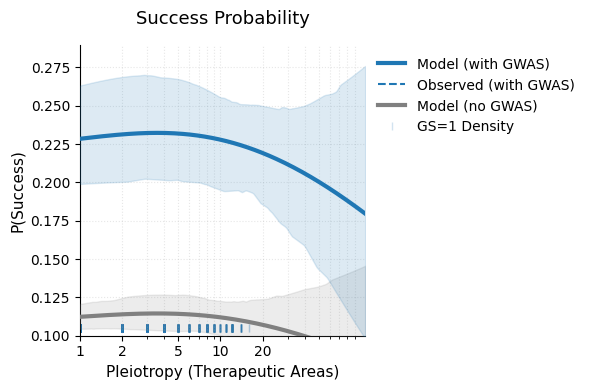

In [22]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from matplotlib.ticker import ScalarFormatter
from scipy.interpolate import interp1d

# 1. Подготовка данных и базовой модели
df_full = df.copy()
# Замена переменной в формуле
formula = "outcome ~ geneticSupport_old + I(np.log(uniqueDiseases+1)) + I(np.log(uniqueDiseases+1) ** 2)"
base_model = smf.logit(formula, data=df_full).fit(disp=False)

# Сетка для предсказаний
x_min, x_max = df_full[df_full["uniqueDiseases"] >= 1]["uniqueDiseases"].agg(["min", "max"])
x_grid = np.geomspace(x_min, x_max, 200)

pred_df_gs1 = pd.DataFrame({"geneticSupport_old": 1, "uniqueDiseases": x_grid})
pred_df_gs0 = pd.DataFrame({"geneticSupport_old": 0, "uniqueDiseases": x_grid})
# 2. Бутстрап (Модели для обеих групп + Lowess только для GS=1)
B = 200
rng = np.random.default_rng(42)

res = {"logit_gs1": [], "logit_gs0": [], "lowess_gs1": []}

print(f"Running bootstrap (B={B})...")
for i in range(B):
    boot_idx = rng.integers(0, len(df_full), len(df_full))
    df_boot = df_full.iloc[boot_idx]

    # А. Логит (Parametric)
    try:
        m = smf.logit(formula, data=df_boot).fit(disp=False)
        res["logit_gs1"].append(m.predict(pred_df_gs1).values)
        res["logit_gs0"].append(m.predict(pred_df_gs0).values)
    except:
        continue

    # Б. Lowess (Empirical) только для GS=1
    sub = df_boot[(df_boot["geneticSupport_old"] == 1) & (df_boot["uniqueDiseases"] >= 1)]
    if sub["uniqueDiseases"].nunique() > 3:
        try:
            lw = sm.nonparametric.lowess(sub["outcome"], sub["uniqueDiseases"], frac=0.5)
            _, u_idx = np.unique(lw[:, 0], return_index=True)
            f_interp = interp1d(lw[u_idx, 0], lw[u_idx, 1], bounds_error=False, fill_value="extrapolate")
            p = f_interp(x_grid)
            if not np.isnan(p).any():
                res["lowess_gs1"].append(p)
        except:
            continue


def get_ci(data):
    arr = np.array(data)
    return np.nanmean(arr, axis=0), np.nanpercentile(arr, [2.5, 97.5], axis=0)


l_m1, l_ci1 = get_ci(res["logit_gs1"])
l_m0, l_ci0 = get_ci(res["logit_gs0"])
w_m1, w_ci1 = get_ci(res["lowess_gs1"])

# 3. Визуализация
fig, ax = plt.subplots(figsize=(6, 4))

# --- Модель GS=1 (Синий) ---
ax.plot(x_grid, base_model.predict(pred_df_gs1), color="#1f77b4", lw=3, label="Model (with GWAS)", zorder=10)
ax.fill_between(x_grid, l_ci1[0], l_ci1[1], color="#1f77b4", alpha=0.15, zorder=9)

# --- Lowess GS=1 (Пунктир) ---
ax.plot(x_grid, w_m1, color="#1f77b4", lw=1.5, ls="--", label="Observed (with GWAS)", zorder=8)
ax.fill_between(x_grid, w_ci1[0], w_ci1[1], color="#1f77b4", alpha=0.07, zorder=7)

# --- Модель GS=0 (Серый) ---
ax.plot(x_grid, base_model.predict(pred_df_gs0), color="gray", lw=3, label="Model (no GWAS)", zorder=6)
ax.fill_between(x_grid, l_ci0[0], l_ci0[1], color="gray", alpha=0.15, zorder=5)

# Rug plot (плотность данных)
ax.plot(
    df_full[df_full["geneticSupport_old"] == 1]["uniqueTherapeuticAreas"],
    np.full(len(df_full[df_full["geneticSupport_old"] == 1]), 0.105),
    "|",
    color="#1f77b4",
    alpha=0.2,
    label="GS=1 Density",
    zorder=1,
)

# Оформление
ax.set_xscale("log")
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.set_xticks([1, 2, 5, 10, 20])  # Подкорректировал тики под типичное кол-во областей
ax.set_xlim(x_min, x_max)
ax.set_ylim(bottom=0.1)

ax.set_xlabel("Pleiotropy (Therapeutic Areas)", fontsize=11)
ax.set_ylabel("P(Success)", fontsize=11)
ax.set_title("Success Probability", fontsize=13, pad=15)
ax.grid(True, which="both", ls=":", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()


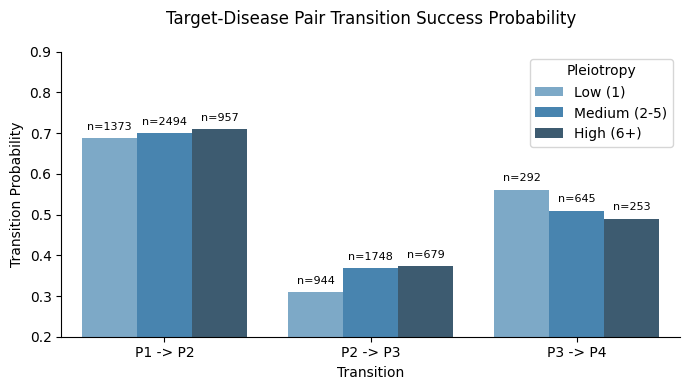

Pleiotropy  High (6+)  Low (1)  Medium (2-5)
Transition                                  
P1 -> P2        0.710    0.688         0.701
P2 -> P3        0.373    0.309         0.369
P3 -> P4        0.490    0.562         0.510


In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Группировка
df_phase = df.copy()
# Используем ручные границы для биологического смысла
bins = [0, 1, 5, float("inf")]
labels = ["Low (1)", "Medium (2-5)", "High (6+)"]
df_phase["pleio_bin"] = pd.cut(df_phase["uniqueTherapeuticAreas"], bins=bins, labels=labels)

# 2. Расчет переходов
transitions = [(1, 2, "P1 -> P2"), (2, 3, "P2 -> P3"), (3, 4, "P3 -> P4")]
transition_results = []

for label in labels:
    subset = df_phase[df_phase["pleio_bin"] == label]
    for start_f, end_f, name in transitions:
        # Кто дошел до текущей фазы
        at_start = len(subset[subset["maxClinicalPhase"] >= start_f])
        # Кто из них прошел в следующую
        at_end = len(subset[subset["maxClinicalPhase"] >= end_f])

        rate = at_end / at_start if at_start > 0 else 0
        transition_results.append(
            {"Pleiotropy": label, "Transition": name, "Success Rate": rate, "N_at_start": at_start}
        )

trans_df = pd.DataFrame(transition_results)

# 3. Визуализация
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=trans_df, x="Transition", y="Success Rate", hue="Pleiotropy", palette="Blues_d", ax=ax)

# Добавляем n=... над столбцами
for i, p in enumerate(ax.patches):
    height = p.get_height()
    if height > 0:
        ax.text(
            p.get_x() + p.get_width() / 2.0,
            height + 0.02,
            f"n={trans_df['N_at_start'].iloc[i]}",
            ha="center",
            fontsize=8,
        )

ax.set_ylim(0.2, 0.9)
ax.set_ylabel("Transition Probability")
ax.set_title("Target-Disease Pair Transition Success Probability", pad=20)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

# Печатаем таблицу для контроля
print(trans_df.pivot(index="Transition", columns="Pleiotropy", values="Success Rate").round(3))


In [11]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

# 1. Подготовка данных
df_phase = df.copy()
bins = [0, 1, 5, float("inf")]
labels = ["Low (1)", "Medium (2-5)", "High (6+)"]
df_phase["pleio_bin"] = pd.cut(df_phase["uniqueTherapeuticAreas"], bins=bins, labels=labels)

transitions = [(1, 2, "P1 -> P2"), (2, 3, "P2 -> P3"), (3, 4, "P3 -> P4")]
final_rows = []

for start_f, end_f, stage_name in transitions:
    stats = {}
    contingency_table = []

    for label in labels:
        subset = df_phase[df_phase["pleio_bin"] == label]
        n_in = len(subset[subset["maxClinicalPhase"] >= start_f])
        n_out = len(subset[subset["maxClinicalPhase"] >= end_f])
        n_fail = n_in - n_out
        rate = (n_out / n_in * 100) if n_in > 0 else 0

        stats[label] = {"n": n_in, "rate": rate}
        contingency_table.append([n_out, n_fail])

    # Считаем общий P-value (Chi-square) для этапа: влияет ли плейотропия на успех?
    chi2, p_val, dof, ex = chi2_contingency(contingency_table)

    final_rows.append(
        {
            "Stage": stage_name,
            "Low (N)": stats["Low (1)"]["n"],
            "Low %": f"{stats['Low (1)']['rate']:.1f}%",
            "Medium (N)": stats["Medium (2-5)"]["n"],
            "Medium %": f"{stats['Medium (2-5)']['rate']:.1f}%",
            "High (N)": stats["High (6+)"]["n"],
            "High %": f"{stats['High (6+)']['rate']:.1f}%",
            "Overall P-value": f"{p_val:.4f}",
        }
    )

# 2. Оформление таблицы
table_complete = pd.DataFrame(final_rows)
print(table_complete.to_string(index=False))


   Stage  Low (N) Low %  Medium (N) Medium %  High (N) High % Overall P-value
P1 -> P2     1373 68.8%        2494    70.1%       957  71.0%          0.4968
P2 -> P3      944 30.9%        1748    36.9%       679  37.3%          0.0041
P3 -> P4      292 56.2%         645    51.0%       253  49.0%          0.2043
